# Exercise 18
**Cristina Correa - 1819211867**


To check an example of correctly classified and misclassified images, we can
search for the labels of the predictions and compare them to the labels of the dataset.

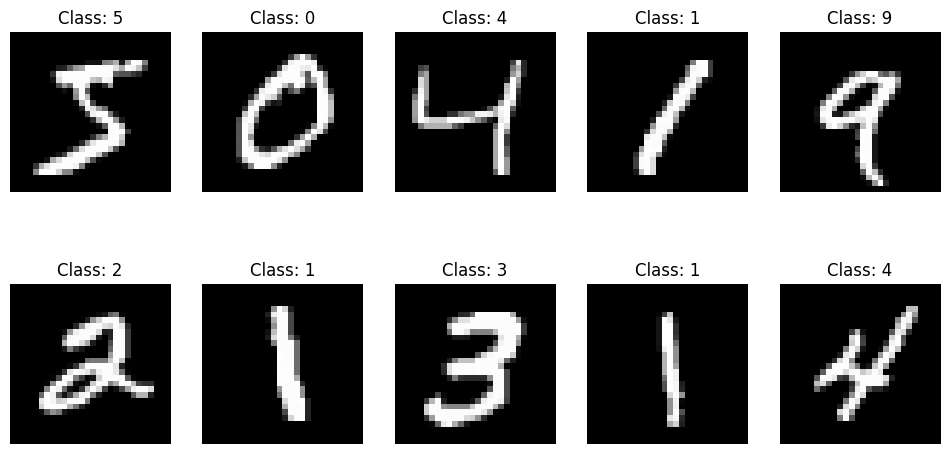

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.8648 - loss: 0.4420 - val_accuracy: 0.9850 - val_loss: 0.0498
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9827 - loss: 0.0561 - val_accuracy: 0.9876 - val_loss: 0.0379
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.9880 - loss: 0.0374 - val_accuracy: 0.9890 - val_loss: 0.0359
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.9912 - loss: 0.0269 - val_accuracy: 0.9896 - val_loss: 0.0316
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.9929 - loss: 0.0223 - val_accuracy: 0.9891 - val_loss: 0.0350
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9850 - loss: 0.0440
Test Accuracy: 98.91%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


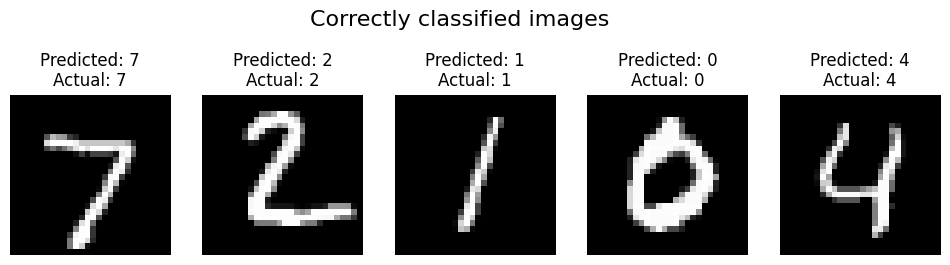

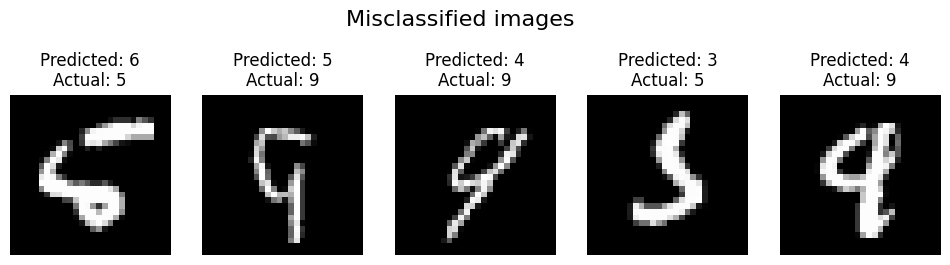

In [3]:
import matplotlib.pyplot as plt
import numpy as np

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.utils import to_categorical
from keras.datasets import mnist


# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Reshape the images and normalise pixel values to be between 0 and 1
X_train = X_train.reshape(-1, 28, 28, 1).astype("float64") / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype("float64") / 255.0

# One-hot encode the labels
y_train_encoded = to_categorical(y_train, 10)
y_test_encoded = to_categorical(y_test, 10)

# Display images and corresponding class names
num_rows, num_cols = 2, 5  # Display 2 rows and 5 columns of images
plt.figure(figsize=(12, 6))
for i in range(num_rows * num_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Class: {y_train[i]}")
    plt.axis("off")
plt.show()

# Build the CNN model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(Flatten())
model.add(Dense(64, activation="relu"))
model.add(Dense(10, activation="softmax"))

# Compile the model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Train the model
model.fit(
    X_train,
    y_train_encoded,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test_encoded),
)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test_encoded)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Predictions on the test set
predictions = model.predict(X_test)

# Find indices of correctly and incorrectly classified images
correct_indices = np.where(np.argmax(predictions, axis=1) == np.argmax(y_test_encoded, axis=1))[0]
incorrect_indices = np.where(np.argmax(predictions, axis=1) != np.argmax(y_test_encoded, axis=1))[0]

# Display examples of correctly classified images
num_examples = 5
plt.figure(figsize=(12, 6))
plt.suptitle("Correctly classified images", fontsize=16)

for i in range(num_examples):
    plt.subplot(2, num_examples, i + 1)
    plt.imshow(X_test[correct_indices[i]].reshape(28, 28), cmap="gray")
    plt.title(
        f"Predicted: {np.argmax(predictions[correct_indices[i]])}\nActual: {np.argmax(y_test_encoded[correct_indices[i]])}"
    )
    plt.axis("off")

# Display examples of misclassified images
plt.figure(figsize=(12, 6))
plt.suptitle("Misclassified images", fontsize=16)

for i in range(num_examples):
    plt.subplot(2, num_examples, i + 1)
    plt.imshow(X_test[incorrect_indices[i]].reshape(28, 28), cmap="gray")
    plt.title(
        f"Predicted: {np.argmax(predictions[incorrect_indices[i]])}\nActual: {np.argmax(y_test_encoded[incorrect_indices[i]])}"
    )
    plt.axis("off")

plt.show()